# Exercice 1 : IBM Challenge 2021

In [54]:
# getting rid of unnecessary warnings
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram, plot_bloch_vector, plot_bloch_multivector

from numpy import pi

### X gate

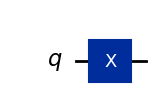

In [47]:
xgate = QuantumCircuit(1)
xgate.x(0)
xgate.draw("mpl")

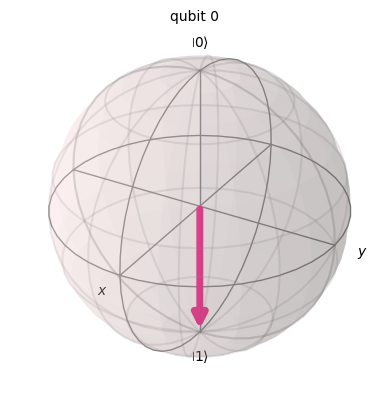

In [48]:
# run simulation
state = Statevector.from_instruction(xgate)
plot_bloch_multivector(state)

### SX Gate

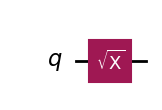

In [50]:
sxgate = QuantumCircuit(1)
sxgate.sx(0)
sxgate.draw("mpl")

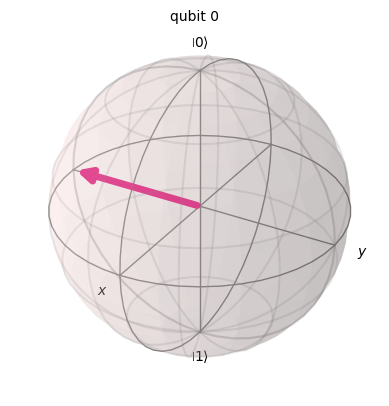

In [52]:
state = Statevector.from_instruction(sxgate)
plot_bloch_multivector(state)

### RZ gate

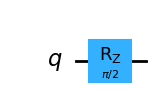

In [55]:
rzgate = QuantumCircuit(1)
rzgate.rz(pi/2, 0)
rzgate.draw("mpl")

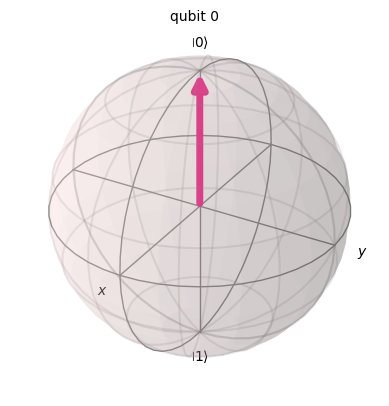

In [56]:
state = Statevector.from_instruction(rzgate)
plot_bloch_multivector(state)
# we not see the differnce state because with just modify the phase

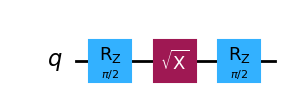

In [57]:
rzgate.sx(0)
rzgate.rz(pi/2, 0)
rzgate.draw("mpl")

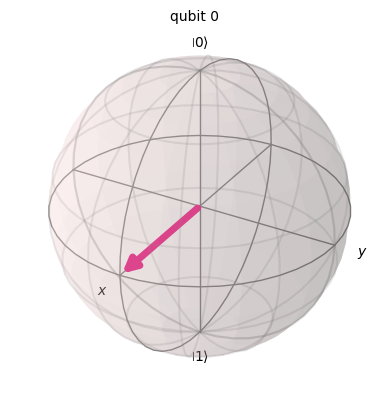

In [59]:
state = Statevector.from_instruction(rzgate)
plot_bloch_multivector(state)

### Hadamard Gate


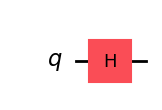

In [60]:
hGate = QuantumCircuit(1)
hGate.h(0)
hGate.draw("mpl")

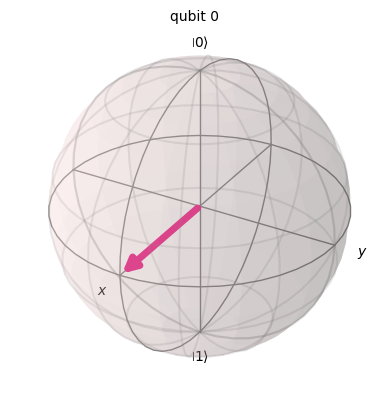

In [61]:
state = Statevector.from_instruction(hGate)
plot_bloch_multivector(state)

### CX Gate

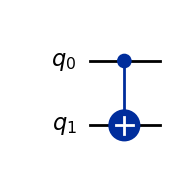

In [62]:
cxgate = QuantumCircuit(2)
cxgate.cx(0,1)
cxgate.draw("mpl")

### CCX Gate

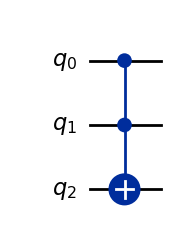

In [64]:
ccxgate = QuantumCircuit(3)
ccxgate.ccx(0,1,2)
ccxgate.draw("mpl")

### Not gate

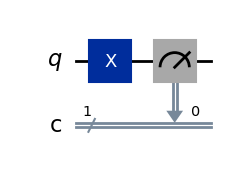

In [66]:
notGate = QuantumCircuit(1, 1)
notGate.x(0)
notGate.measure(0,0)
notGate.draw("mpl")

### AND Gate

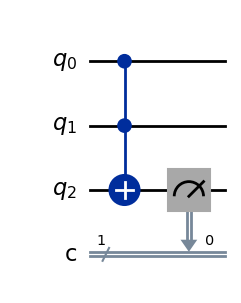

In [67]:
AndGate = QuantumCircuit(3,1)
AndGate.ccx(0,1,2)
AndGate.measure(2,0)
AndGate.draw("mpl")

### OR Gate

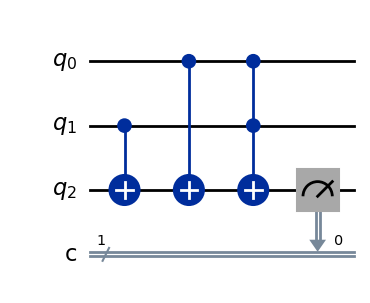

In [68]:
OrGate = QuantumCircuit(3,1)
OrGate.cx(1,2)
OrGate.cx(0,2)
OrGate.ccx(0,1,2)
OrGate.measure(2,0)
OrGate.draw("mpl")

### Composite quantum gates and their cost

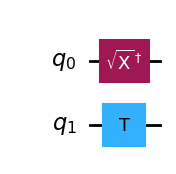

In [70]:
qc = QuantumCircuit(2)
qc.sxdg(0)
qc.t(1)
qc.draw("mpl")

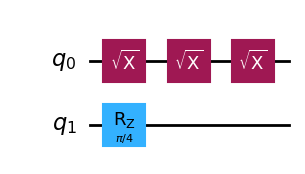

In [71]:
# decomposition of the circuit
qc = QuantumCircuit(2)
qc.sx(0)
qc.sx(0)
qc.sx(0)
qc.rz(pi/4, 1)
qc.draw("mpl")

In [ ]:
# cost of the function
# Cost = 10*N_cnot +N_other

### Hadamard gate

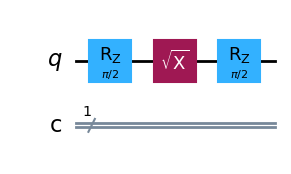

In [72]:
qc = QuantumCircuit(1,1)
qc.rz(pi/2, 0)
qc.sx(0)
qc.rz(pi/2, 0)
qc.draw("mpl")

### Controlled rotation

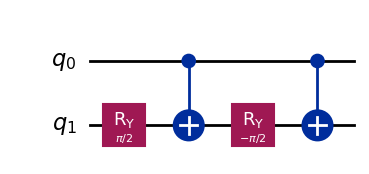

In [74]:
qc = QuantumCircuit(2)
theta = pi
qc.ry(theta/2, 1)
qc.cx(0,1)
qc.ry(-theta/2, 1)
qc.cx(0,1)
qc.draw("mpl")

### Controlled controlled rotation

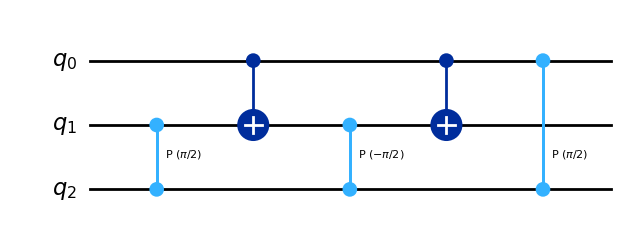

In [76]:
qc = QuantumCircuit(3)
theta = pi
qc.cp(theta/2, 1,2)
qc.cx(0,1)
qc.cp(-theta/2, 1,2)
qc.cx(0,1)
qc.cp(theta/2, 0, 2)
qc.draw("mpl")

### Problem

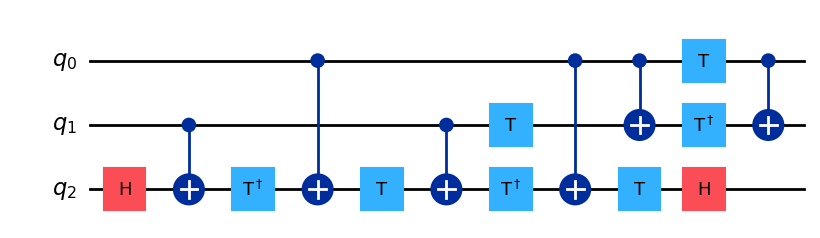

In [78]:
circuit = QuantumCircuit(3)
circuit.ccx(0,1,2)
circuit.decompose().draw("mpl")

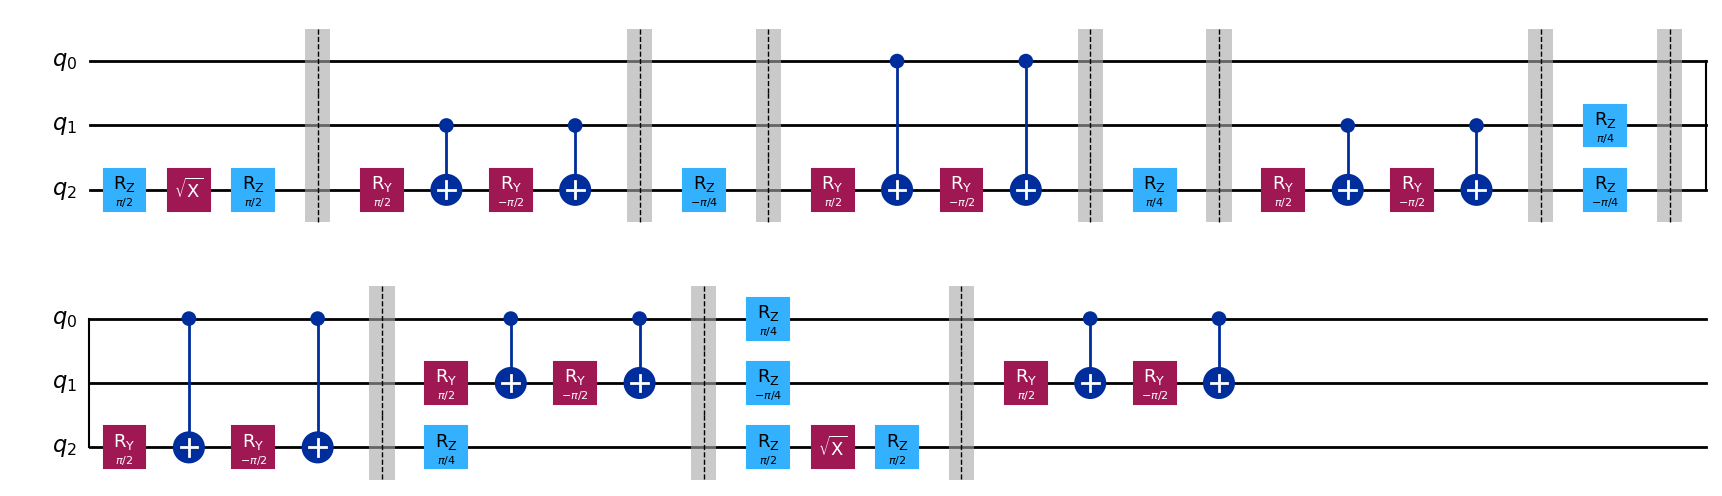

In [100]:
circuit = QuantumCircuit(3)
# hadamard
circuit.rz(pi/2, 2)
circuit.sx(2)
circuit.rz(pi/2, 2)
circuit.barrier()

#Cnot 1
theta = pi
circuit.ry(theta/2, 2)
circuit.cx(1,2)
circuit.ry(-theta/2, 2)
circuit.cx(1,2)
circuit.barrier()

#T dagger
circuit.rz(-pi/4,2)
circuit.barrier()

# Cnot2
circuit.ry(theta/2, 2)
circuit.cx(0,2)
circuit.ry(-theta/2, 2)
circuit.cx(0,2)
circuit.barrier()

#T gate
circuit.rz(pi/4,2)
circuit.barrier()

#Cnot3
circuit.ry(theta/2, 2)
circuit.cx(1,2)
circuit.ry(-theta/2, 2)
circuit.cx(1,2)
circuit.barrier()

# T and T dagger gate
circuit.rz(pi/4,1)
circuit.rz(-pi/4,2)
circuit.barrier()

#Cnot gate4
circuit.ry(theta/2, 2)
circuit.cx(0,2)
circuit.ry(-theta/2, 2)
circuit.cx(0,2)
circuit.barrier()

# Cnot5 and T gates
circuit.rz(pi/4,2)

circuit.ry(theta/2, 1)
circuit.cx(0,1)
circuit.ry(-theta/2, 1)
circuit.cx(0,1)
circuit.barrier()

# T, T dagger and H gates
circuit.rz(pi/4,0)
circuit.rz(-pi/4,1)
circuit.rz(pi/2, 2)
circuit.sx(2)
circuit.rz(pi/2, 2)
circuit.barrier()

# Cnot6 gate
circuit.ry(theta/2, 1)
circuit.cx(0,1)
circuit.ry(-theta/2, 1)
circuit.cx(0,1)

circuit.draw("mpl")

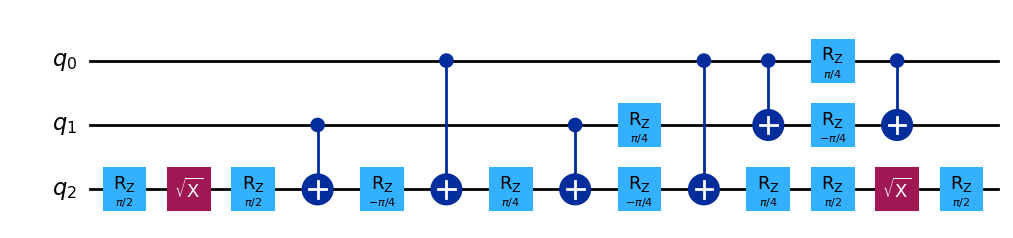

In [104]:
# with cx allowed
circuit = QuantumCircuit(3)
# hadamard
circuit.rz(pi/2, 2)
circuit.sx(2)
circuit.rz(pi/2, 2)

#Cnot 1
circuit.cx(1,2)

#T dagger
circuit.rz(-pi/4,2)

# Cnot2
circuit.cx(0,2)

#T gate
circuit.rz(pi/4,2)

#Cnot3
circuit.cx(1,2)

# T and T dagger gate
circuit.rz(pi/4,1)
circuit.rz(-pi/4,2)

#Cnot gate4
circuit.cx(0,2)

# Cnot5 and T gates
circuit.rz(pi/4,2)
circuit.cx(0,1)

# T, T dagger and H gates
circuit.rz(pi/4,0)
circuit.rz(-pi/4,1)
circuit.rz(pi/2, 2)
circuit.sx(2)
circuit.rz(pi/2, 2)

# Cnot6 gate
circuit.cx(0,1)

circuit.draw("mpl")